# Random Forest - PM2.5 Forecasting

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('ggplot')

In [55]:
# === CONFIG ===
LAG_DAYS = 14        # จำนวนวัน PM2.5 ย้อนหลังที่ใช้เป็น feature
FORECAST_DAYS = 7   # จำนวนวันที่ต้องการพยากรณ์ล่วงหน้า
RANDOM_STATE = 42

# Load dataset
data = pd.read_csv('../data/dataset/dataset.csv', parse_dates=['date'])
data = data.sort_values(['station', 'date']).reset_index(drop=True)

# Weather feature columns (ไม่รวม pm25, date, station)
weather_cols = [c for c in data.columns if c not in ['pm25', 'date', 'station']]
print(f"Loaded: {data.shape}")
print(f"Weather features: {weather_cols}")
data.head()

Loaded: (18270, 13)
Weather features: ['dew_point_2m_mean', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean', 'surface_pressure_mean', 'relative_humidity_2m_mean', 'wind_dir_sin', 'wind_dir_cos', 'month_sin', 'month_cos']


,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25,station,wind_dir_sin,wind_dir_cos,month_sin,month_cos
0,2021-01-01,12.8,22.1,0.0,9.5,1014.3,56,20.0,05T,0.754710,0.656059,0.5,0.866025
1,2021-01-02,14.9,22.1,0.0,6.5,1013.5,64,25.0,05T,0.173648,0.984808,0.5,0.866025
2,2021-01-03,16.2,23.5,0.0,7.8,1012.1,65,37.0,05T,0.292372,0.956305,0.5,0.866025
3,2021-01-04,17.8,25.0,0.0,7.6,1011.8,65,31.0,05T,0.406737,0.913545,0.5,0.866025
4,2021-01-05,19.3,25.5,0.0,5.9,1011.8,69,31.0,05T,0.358368,0.933580,0.5,0.866025


In [56]:
# === Create Features for 1-step-ahead Forecasting ===
# Concept: ใช้ข้อมูลวัน T เพื่อทำนาย PM2.5 วัน T+1
# Features: weather(T) + pm25(T) + pm25(T-1) + ... + pm25(T-6)  [7 วันย้อนหลัง]
# Target:   pm25(T+1)

# สร้าง PM2.5 lag features ภายในแต่ละสถานี
# pm25 column = วัน T (ค่าปัจจุบัน, ใช้เป็น feature)
# pm25_lag1 = วัน T-1, ..., pm25_lag6 = วัน T-6
for lag in range(1, LAG_DAYS):
    data[f'pm25_lag{lag}'] = data.groupby('station')['pm25'].shift(lag)

# Target: PM2.5 วันถัดไป (T+1)
data['pm25_next'] = data.groupby('station')['pm25'].shift(-1)

# Drop rows with NaN
before = len(data)
data = data.dropna().reset_index(drop=True)
print(f"After feature engineering: {data.shape} (dropped {before - len(data)} rows)")

# Define feature columns & target
feature_cols = weather_cols + ['pm25'] + [f'pm25_lag{i}' for i in range(1, LAG_DAYS)]
target_col = 'pm25_next'

print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"Target: {target_col}")
data.head()

After feature engineering: (18130, 27) (dropped 140 rows)

Features (24): ['dew_point_2m_mean', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean', 'surface_pressure_mean', 'relative_humidity_2m_mean', 'wind_dir_sin', 'wind_dir_cos', 'month_sin', 'month_cos', 'pm25', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag4', 'pm25_lag5', 'pm25_lag6', 'pm25_lag7', 'pm25_lag8', 'pm25_lag9', 'pm25_lag10', 'pm25_lag11', 'pm25_lag12', 'pm25_lag13']
Target: pm25_next


,date,dew_point_2m_mean,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean,surface_pressure_mean,relative_humidity_2m_mean,pm25,station,wind_dir_sin,...,pm25_lag5,pm25_lag6,pm25_lag7,pm25_lag8,pm25_lag9,pm25_lag10,pm25_lag11,pm25_lag12,pm25_lag13,pm25_next
0,2021-01-14,13.8,21.8,0.0,5.8,1012.0,62,71.0,05T,-0.587785,...,19.0,21.0,26.0,32.0,31.0,31.0,37.0,25.0,20.0,83.0
1,2021-01-15,16.6,23.4,0.0,6.7,1009.8,69,83.0,05T,-0.422618,...,27.0,19.0,21.0,26.0,32.0,31.0,31.0,37.0,25.0,66.0
2,2021-01-16,19.9,24.5,0.0,7.4,1009.8,78,66.0,05T,-0.325568,...,27.0,27.0,19.0,21.0,26.0,32.0,31.0,31.0,37.0,44.0
3,2021-01-17,18.6,26.1,0.1,10.5,1011.9,68,44.0,05T,0.882948,...,26.0,27.0,27.0,19.0,21.0,26.0,32.0,31.0,31.0,29.0
4,2021-01-18,13.1,23.9,0.0,17.0,1013.7,52,29.0,05T,0.898794,...,48.0,26.0,27.0,27.0,19.0,21.0,26.0,32.0,31.0,45.0


In [57]:
# === Time-based Train / Validation / Test Split ===
# Train: 2021-2023 | Validation: 2024 | Test: 2025

train = data[data['date'] < '2024-01-01']
val   = data[(data['date'] >= '2024-01-01') & (data['date'] < '2025-01-01')]
test  = data[data['date'] >= '2025-01-01']

X_train, y_train = train[feature_cols], train[target_col]
X_val,   y_val   = val[feature_cols],   val[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

print(f"Train: {X_train.shape}  ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Val:   {X_val.shape}  ({val['date'].min().date()} to {val['date'].max().date()})")
print(f"Test:  {X_test.shape}  ({test['date'].min().date()} to {test['date'].max().date()})")

Train: (10830, 24)  (2021-01-14 to 2023-12-31)
Val:   (3660, 24)  (2024-01-01 to 2024-12-31)
Test:  (3640, 24)  (2025-01-01 to 2025-12-30)


In [58]:
# === Optuna Hyperparameter Tuning (1-step-ahead on validation) ===
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth':         trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state':      RANDOM_STATE,
        'n_jobs':            -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    return mean_squared_error(y_val, y_pred_val)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest MSE (val): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best trial: 44. Best value: 58.9641: 100%|██████████| 50/50 [02:04<00:00,  2.49s/it]


Best MSE (val): 58.9641
Best params: {'n_estimators': 450, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None}


In [59]:
# === Train Final Model ===
best_params = study.best_params
best_params['random_state'] = RANDOM_STATE
best_params['n_jobs'] = -1

rf_best = RandomForestRegressor(**best_params)
rf_best.fit(X_train, y_train)
print("Model trained with best params:", best_params)

Model trained with best params: {'n_estimators': 450, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None, 'random_state': 42, 'n_jobs': -1}


In [60]:
# === 1-Step-Ahead Evaluation ===
def evaluate(y_true, y_pred, name):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mbe  = np.mean(y_pred - y_true)
    print(f"[{name}]  R²={r2:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MBE={mbe:.4f}")
    return {'Set': name, 'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MBE': mbe}

y_pred_train = rf_best.predict(X_train)
y_pred_val   = rf_best.predict(X_val)
y_pred_test  = rf_best.predict(X_test)

print("=== 1-Step-Ahead (ทำนายวันถัดไป) ===")
results = []
results.append(evaluate(y_train, y_pred_train, 'Train'))
results.append(evaluate(y_val,   y_pred_val,   'Validation'))
results.append(evaluate(y_test,  y_pred_test,  'Test'))

pd.DataFrame(results).set_index('Set')

=== 1-Step-Ahead (ทำนายวันถัดไป) ===
[Train]  R²=0.9237  MSE=43.2101  RMSE=6.5734  MAE=3.5456  MBE=-0.0009
[Validation]  R²=0.8604  MSE=58.9641  RMSE=7.6788  MAE=4.2649  MBE=-0.2112
[Test]  R²=0.8670  MSE=55.0303  RMSE=7.4182  MAE=3.8207  MBE=0.1185


,R2,MSE,RMSE,MAE,MBE
Set,,,,,
Train,0.923713,43.210060,6.573436,3.545636,-0.000886
Validation,0.860401,58.964066,7.678806,4.264943,-0.211244
Test,0.866978,55.030349,7.418244,3.820703,0.118475


In [61]:
# === Recursive Multi-Step Forecasting (7 วันล่วงหน้า, sliding window ทีละ 1 วัน) ===
# วิธีการ: ทำนายวันที่ 1 → ใส่ผลทำนายกลับเป็น lag → ทำนายวันที่ 2 → ... → วันที่ 7
#
# ตัวอย่าง: ณ วัน T ต้องการทำนาย T+1 ถึง T+7
#   Step 1: features = weather(T) + [pm25(T), pm25(T-1), ..., pm25(T-6)] → pred(T+1)
#   Step 2: features = weather(T+1) + [pred(T+1), pm25(T), ..., pm25(T-5)] → pred(T+2)
#   ...
#   Step 7: features = weather(T+6) + [pred(T+6), ..., pred(T+1)] → pred(T+7)

# pm25 lag column names ตามลำดับ (ล่าสุด → เก่าสุด)
pm25_lag_cols = ['pm25'] + [f'pm25_lag{i}' for i in range(1, LAG_DAYS)]

def recursive_forecast(model, test_df, stations, forecast_days, feature_cols, pm25_lag_cols):
    """Recursive multi-step forecast with sliding window (step=1 day)."""
    all_results = []
    
    for station in stations:
        st_data = test_df[test_df['station'] == station].sort_values('date').reset_index(drop=True)
        
        # Sliding window: ทุกๆ วันเป็น origin (ขยับทีละ 1 วัน)
        for origin_idx in range(len(st_data) - forecast_days):
            # PM2.5 history ณ จุด origin (7 ค่าล่าสุด)
            pm25_history = [st_data.loc[origin_idx, col] for col in pm25_lag_cols]
            
            for step in range(1, forecast_days + 1):
                target_idx = origin_idx + step
                if target_idx >= len(st_data):
                    break
                
                # weather มาจากวัน T+(step-1) ซึ่งเป็นข้อมูลวันก่อนหน้า target
                weather_idx = origin_idx + step - 1
                if weather_idx >= len(st_data):
                    break
                
                row_features = {}
                for col in weather_cols:
                    row_features[col] = st_data.loc[weather_idx, col]
                for i, col in enumerate(pm25_lag_cols):
                    row_features[col] = pm25_history[i]
                
                X_row = pd.DataFrame([row_features])[feature_cols]
                pred = model.predict(X_row)[0]
                
                # อัปเดต PM2.5 history: ใส่ค่า predicted เข้าไปข้างหน้า, เลื่อนเก่าออก
                pm25_history = [pred] + pm25_history[:-1]
                
                # actual = PM2.5 ของวัน target (origin + step)
                actual = st_data.loc[target_idx, 'pm25']
                all_results.append({
                    'station': station,
                    'origin_date': st_data.loc[origin_idx, 'date'],
                    'target_date': st_data.loc[target_idx, 'date'],
                    'horizon': step,
                    'actual': actual,
                    'predicted': pred,
                })
    
    return pd.DataFrame(all_results)

stations = data['station'].unique()
forecast_results = recursive_forecast(rf_best, test, stations, FORECAST_DAYS, feature_cols, pm25_lag_cols)
print(f"Recursive forecast results: {len(forecast_results)} predictions")
print(f"Origins per station: {forecast_results.groupby('station')['origin_date'].nunique().iloc[0]}")
forecast_results.head(14)

Recursive forecast results: 24990 predictions
Origins per station: 357


,station,origin_date,target_date,horizon,actual,predicted
0,05T,2025-01-01,2025-01-02,1,36.6,41.259050
1,05T,2025-01-01,2025-01-03,2,34.5,43.383802
2,05T,2025-01-01,2025-01-04,3,32.8,44.018219
3,05T,2025-01-01,2025-01-05,4,35.5,44.254024
4,05T,2025-01-01,2025-01-06,5,40.3,45.940922
5,05T,2025-01-01,2025-01-07,6,51.7,48.506441
6,05T,2025-01-01,2025-01-08,7,63.3,49.592856
7,05T,2025-01-02,2025-01-03,1,34.5,41.965972
8,05T,2025-01-02,2025-01-04,2,32.8,43.563211
9,05T,2025-01-02,2025-01-05,3,35.5,44.245553


In [62]:
# === Evaluation per Forecast Horizon (1-7 days ahead) ===
print("=== Recursive Forecasting Metrics per Horizon ===\n")
horizon_results = []
for h in range(1, FORECAST_DAYS + 1):
    subset = forecast_results[forecast_results['horizon'] == h]
    r2   = r2_score(subset['actual'], subset['predicted'])
    mse  = mean_squared_error(subset['actual'], subset['predicted'])
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(subset['actual'], subset['predicted'])
    mbe  = np.mean(subset['predicted'] - subset['actual'])
    horizon_results.append({'Horizon': f'Day+{h}', 'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MBE': mbe})
    print(f"Day+{h}:  R²={r2:.4f} MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MBE={mbe:.4f}")

horizon_df = pd.DataFrame(horizon_results).set_index('Horizon')
horizon_df

=== Recursive Forecasting Metrics per Horizon ===

Day+1:  R²=0.8670 MSE=55.6509  RMSE=7.4600  MAE=3.8328  MBE=0.1276
Day+2:  R²=0.7636 MSE=98.8034  RMSE=9.9400  MAE=5.2238  MBE=0.2033
Day+3:  R²=0.7092 MSE=121.4619  RMSE=11.0210  MAE=5.9204  MBE=0.2932
Day+4:  R²=0.6752 MSE=135.3219  RMSE=11.6328  MAE=6.2811  MBE=0.3753
Day+5:  R²=0.6534 MSE=143.9227  RMSE=11.9968  MAE=6.5419  MBE=0.4567
Day+6:  R²=0.6268 MSE=154.4319  RMSE=12.4271  MAE=6.7434  MBE=0.5552
Day+7:  R²=0.5992 MSE=164.9714  RMSE=12.8441  MAE=6.9017  MBE=0.6625


,R2,MSE,RMSE,MAE,MBE
Horizon,,,,,
Day+1,0.867016,55.650886,7.459952,3.832822,0.127572
Day+2,0.763611,98.803364,9.939988,5.223766,0.203285
Day+3,0.709222,121.461893,11.020975,5.920450,0.293180
Day+4,0.675169,135.321866,11.632793,6.281120,0.375268
Day+5,0.653449,143.922748,11.996781,6.541888,0.456653
Day+6,0.626754,154.431876,12.427062,6.743402,0.555202
Day+7,0.599246,164.971363,12.844118,6.901686,0.662485


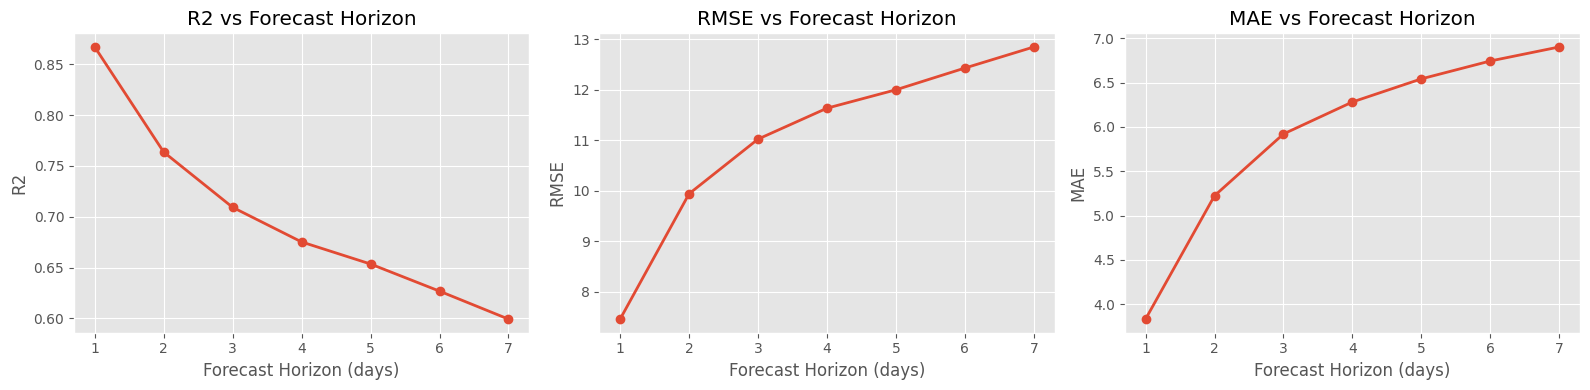

In [63]:
# === Metrics Degradation by Horizon ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    ax.plot(range(1, FORECAST_DAYS + 1), horizon_df[metric], 'o-', linewidth=2)
    ax.set_xlabel('Forecast Horizon (days)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Forecast Horizon')
    ax.set_xticks(range(1, FORECAST_DAYS + 1))

plt.tight_layout()
plt.show()

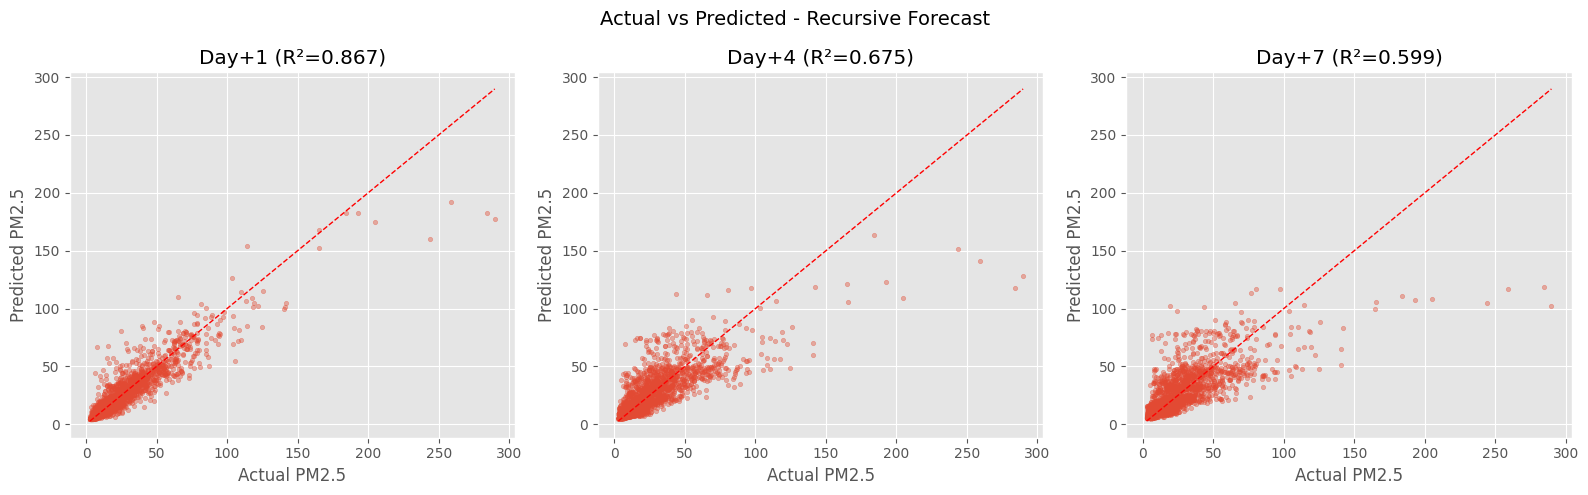

In [64]:
# === Actual vs Predicted Scatter (per horizon: Day+1, Day+4, Day+7) ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, h in zip(axes, [1, 4, 7]):
    subset = forecast_results[forecast_results['horizon'] == h]
    ax.scatter(subset['actual'], subset['predicted'], alpha=0.4, s=10)
    lims = [min(subset['actual'].min(), subset['predicted'].min()),
            max(subset['actual'].max(), subset['predicted'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual PM2.5')
    ax.set_ylabel('Predicted PM2.5')
    r2 = r2_score(subset['actual'], subset['predicted'])
    ax.set_title(f'Day+{h} (R²={r2:.3f})')

plt.suptitle('Actual vs Predicted - Recursive Forecast', fontsize=14)
plt.tight_layout()
plt.show()

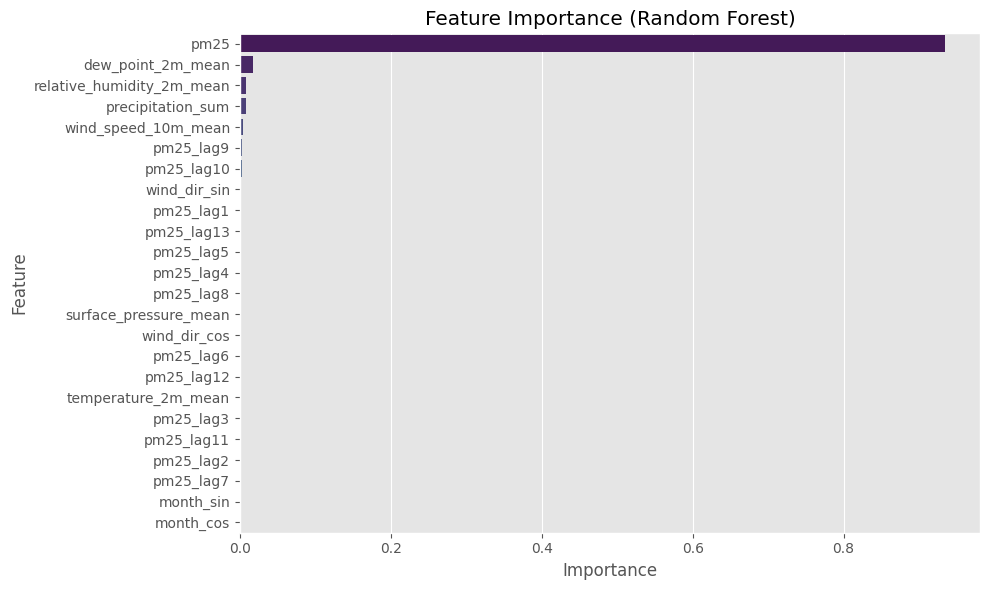

                  Feature  Importance
                     pm25    0.934030
        dew_point_2m_mean    0.017525
relative_humidity_2m_mean    0.008004
        precipitation_sum    0.007716
      wind_speed_10m_mean    0.004040
                pm25_lag9    0.002323
               pm25_lag10    0.002216
             wind_dir_sin    0.002018
                pm25_lag1    0.001937
               pm25_lag13    0.001838
                pm25_lag5    0.001778
                pm25_lag4    0.001709
                pm25_lag8    0.001647
    surface_pressure_mean    0.001522
             wind_dir_cos    0.001421
                pm25_lag6    0.001367
               pm25_lag12    0.001329
      temperature_2m_mean    0.001291
                pm25_lag3    0.001221
               pm25_lag11    0.001145
                pm25_lag2    0.001142
                pm25_lag7    0.001030
                month_sin    0.000966
                month_cos    0.000787


In [65]:
# === Feature Importance ===
fi = pd.DataFrame({'Feature': feature_cols, 'Importance': rf_best.feature_importances_})
fi = fi.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()
print(fi.to_string(index=False))

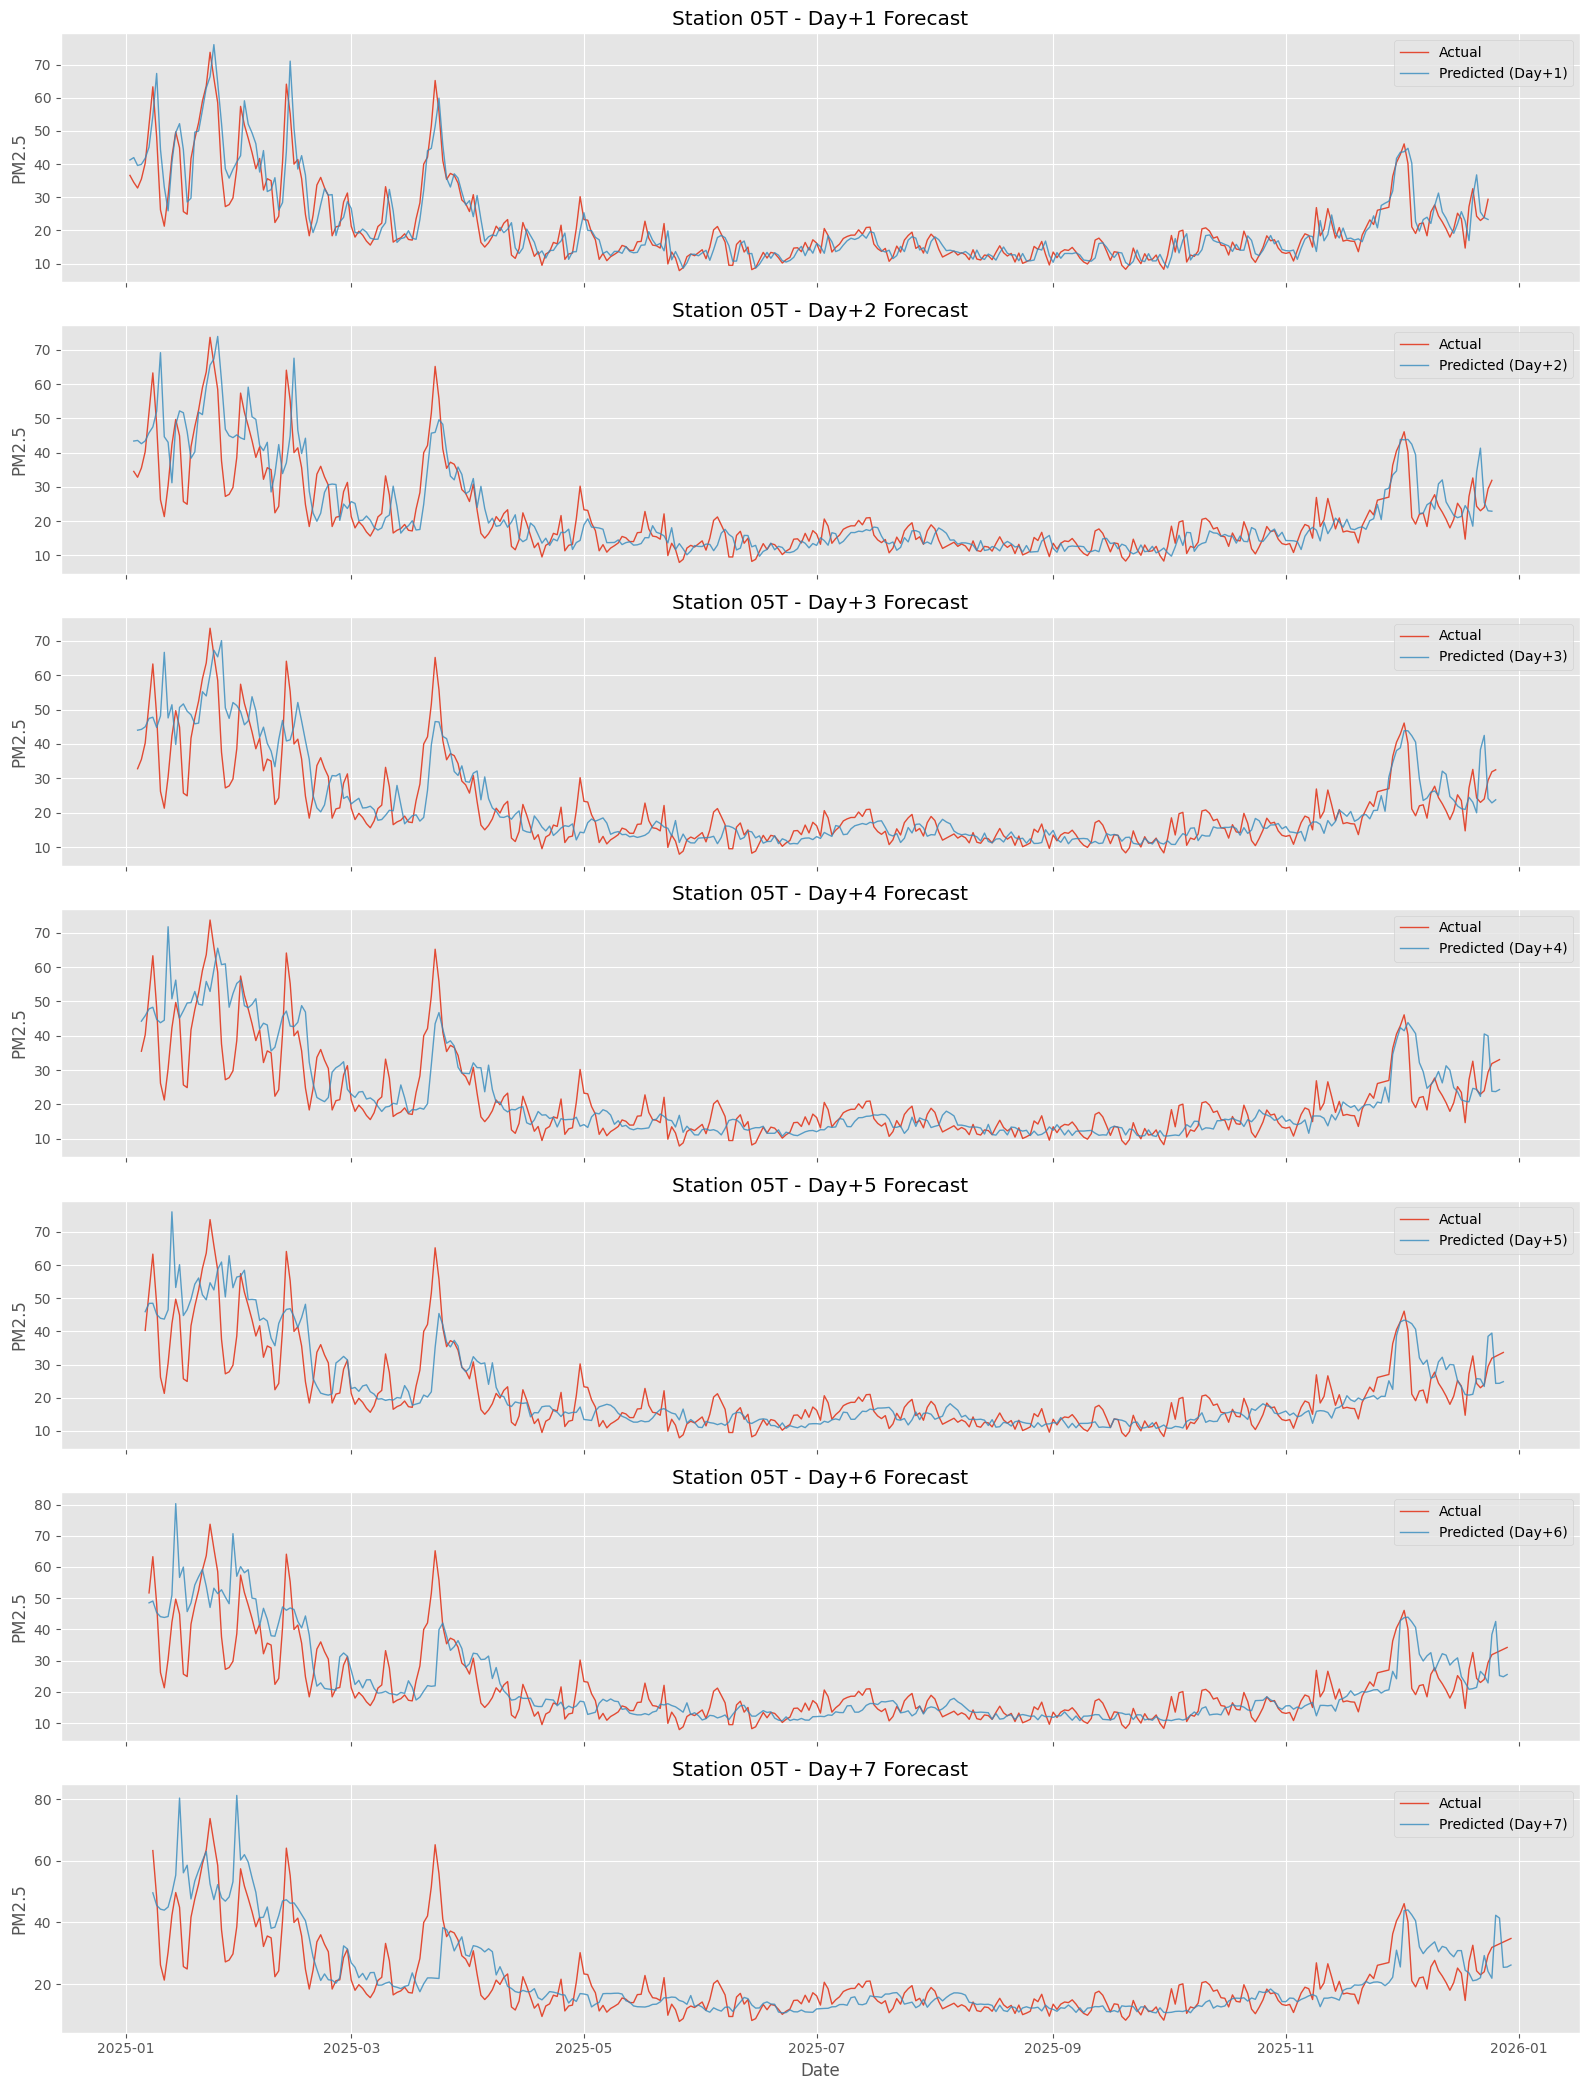

In [66]:
# === Time Series: Recursive 7-day Forecast vs Actual (sample station) ===
sample_station = stations[0]
st_forecast = forecast_results[forecast_results['station'] == sample_station].sort_values('target_date')

fig, axes = plt.subplots(FORECAST_DAYS, 1, figsize=(16, 3 * FORECAST_DAYS), sharex=True)
for i, h in enumerate(range(1, FORECAST_DAYS + 1)):
    sub = st_forecast[st_forecast['horizon'] == h]
    axes[i].plot(sub['target_date'], sub['actual'], label='Actual', linewidth=1)
    axes[i].plot(sub['target_date'], sub['predicted'], label=f'Predicted (Day+{h})', linewidth=1, alpha=0.8)
    axes[i].set_ylabel('PM2.5')
    axes[i].legend(loc='upper right')
    axes[i].set_title(f'Station {sample_station} - Day+{h} Forecast')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

In [67]:
# === Export Model & Config ===
import joblib
import json
import os

export_dir = 'RF_inference'
os.makedirs(export_dir, exist_ok=True)

# Save model
joblib.dump(rf_best, os.path.join(export_dir, 'rf_model.joblib'))

# Save config (feature columns, lag days, etc.)
config = {
    'lag_days': LAG_DAYS,
    'forecast_days': FORECAST_DAYS,
    'feature_cols': feature_cols,
    'weather_cols': weather_cols,
    'pm25_lag_cols': pm25_lag_cols,
}
with open(os.path.join(export_dir, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f"Model saved to {export_dir}/rf_model.joblib")
print(f"Config saved to {export_dir}/model_config.json")

Model saved to RF_inference/rf_model.joblib
Config saved to RF_inference/model_config.json
